In [5]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv("residential_housing(1).csv")

In [13]:
# Summary statistics
summary_data = print(data.describe(include="all"))
summary_data

                 Id   MSSubClass MSZoning  LotFrontage        LotArea Street  \
count   1460.000000  1460.000000     1460  1201.000000    1460.000000   1460   
unique          NaN          NaN        5          NaN            NaN      2   
top             NaN          NaN       RL          NaN            NaN   Pave   
freq            NaN          NaN     1151          NaN            NaN   1454   
mean     730.500000    56.897260      NaN    70.049958   10516.828082    NaN   
std      421.610009    42.300571      NaN    24.284752    9981.264932    NaN   
min        1.000000    20.000000      NaN    21.000000    1300.000000    NaN   
25%      365.750000    20.000000      NaN    59.000000    7553.500000    NaN   
50%      730.500000    50.000000      NaN    69.000000    9478.500000    NaN   
75%     1095.250000    70.000000      NaN    80.000000   11601.500000    NaN   
max     1460.000000   190.000000      NaN   313.000000  215245.000000    NaN   

       Alley LotShape LandContour Utili

In [14]:
# Quartiles

Q1 = data['LotArea'].quantile(0.25)
Q2 = data['LotArea'].quantile(0.50)
Q3 = data['LotArea'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):7553.5, Q2(Second Quartile): 9478.5, and Q3(Third quartile) : 11601.5
Inter Quartile Range :4048.0


In [15]:
#Lower and upper bound

Q1 = data['LotArea'].quantile(0.25)
Q2 = data['LotArea'].quantile(0.50)
Q3 = data['LotArea'].quantile(0.75)

IQR = Q3-Q1

Lower = Q1-1.5*IQR
Upper = Q3 + 1.5 * IQR

print("Lower Bound:\n", Lower)
print("Upper Bound:\n", Upper)

Lower Bound:
 1481.5
Upper Bound:
 17673.5


In [16]:
# Select the relevant attributes
attributes = ['LotArea', 'GrLivArea', 'SalePrice']

# Compute IQR for each attribute
iqr = {}
for col in attributes:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr[col] = q3 - q1

# Display IQRs
print("Interquartile Ranges:")
for col, value in iqr.items():
    print(f"{col}: {value}")

# Identify attribute with maximum IQR
max_iqr_attr = max(iqr, key=iqr.get)
print(f"\nAttribute with highest IQR: {max_iqr_attr}")

Interquartile Ranges:
LotArea: 4048.0
GrLivArea: 647.25
SalePrice: 84025.0

Attribute with highest IQR: SalePrice


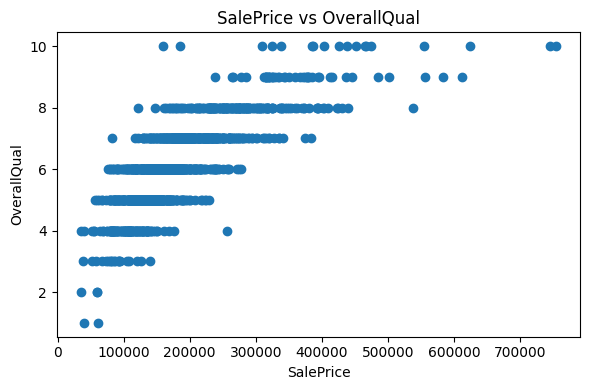

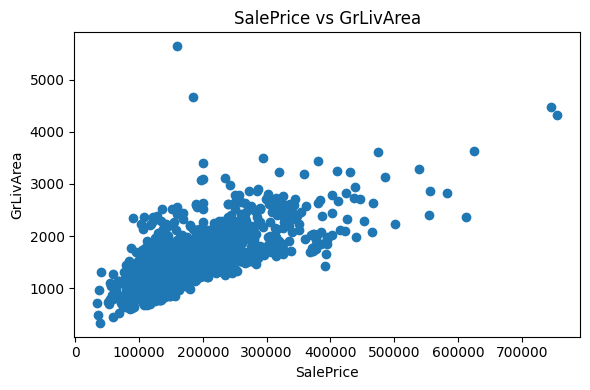

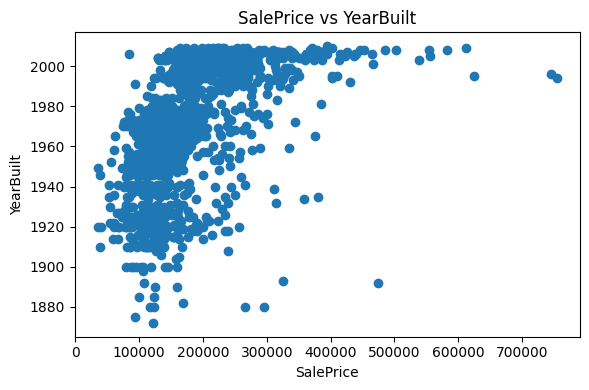

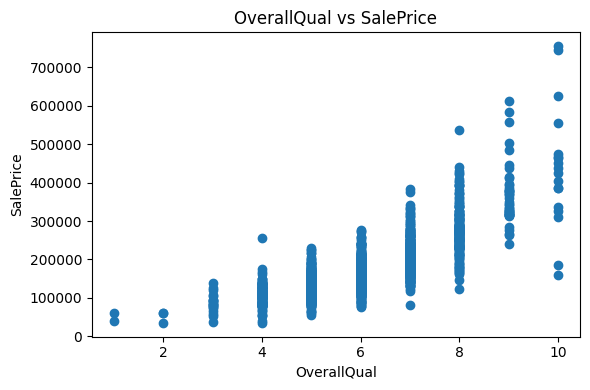

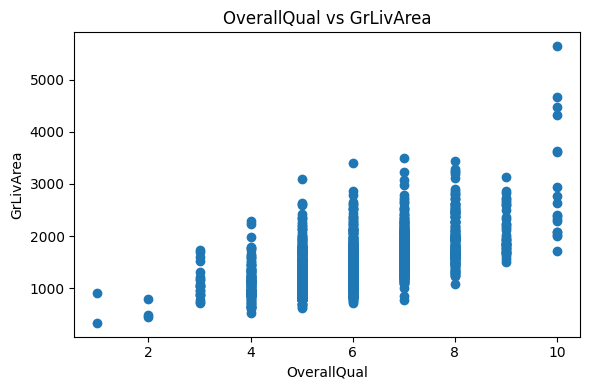

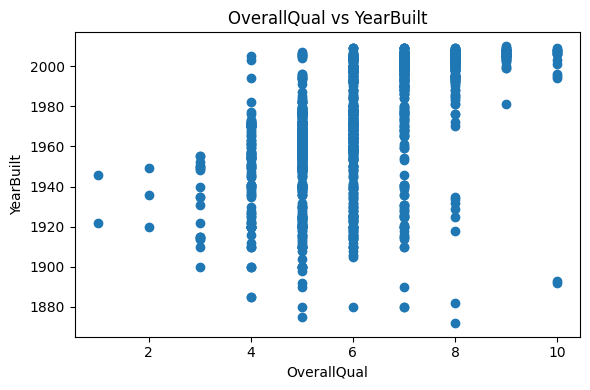

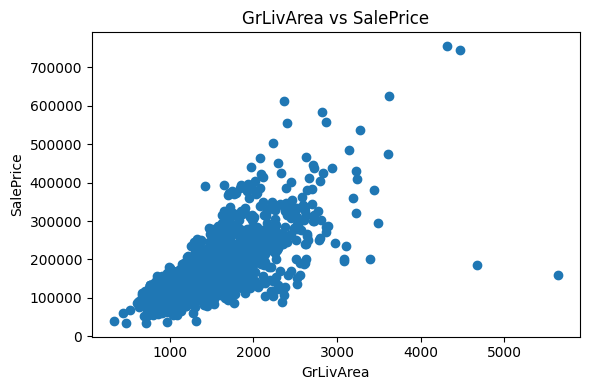

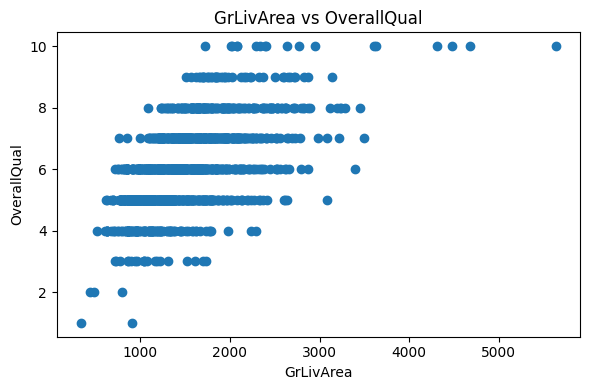

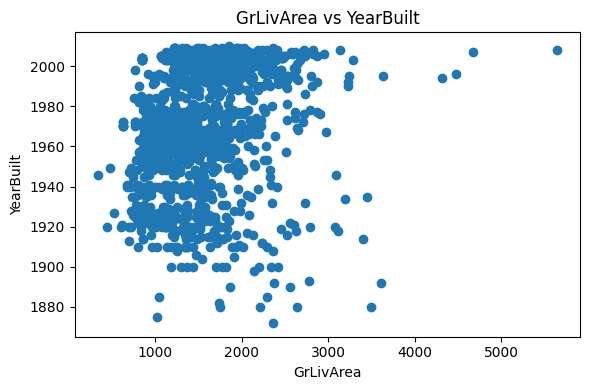

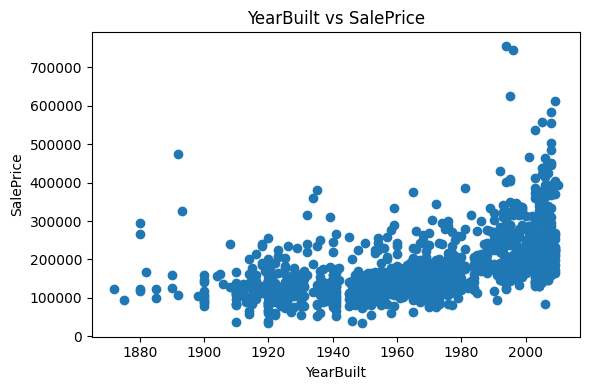

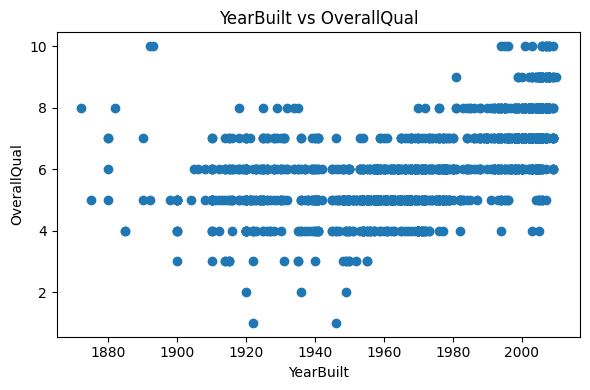

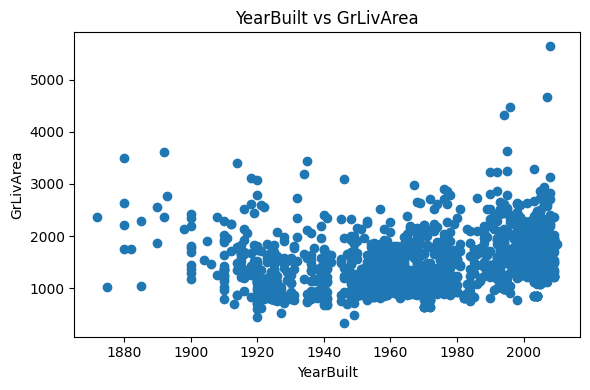

In [17]:
# Select the relevant attributes
attributes = ['SalePrice','OverallQual','GrLivArea','YearBuilt']

#Compute IQR for each attribute

for i in attributes:
    for j in attributes:
        if (j == i):
            continue
        else :
            plt.figure(figsize=(6,4))
            plt.scatter(data[i], data[j])
            plt.xlabel(i)
            plt.ylabel(j)
            plt.title(f"{i} vs {j}")
            plt.tight_layout()
            plt.show()

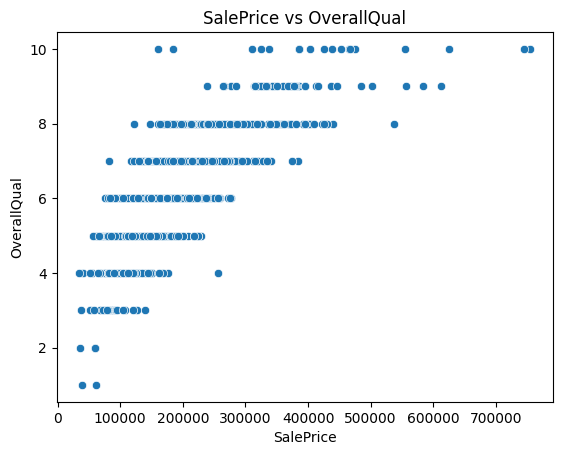

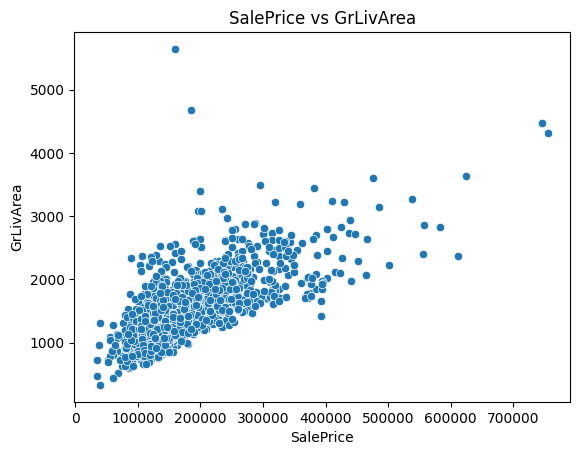

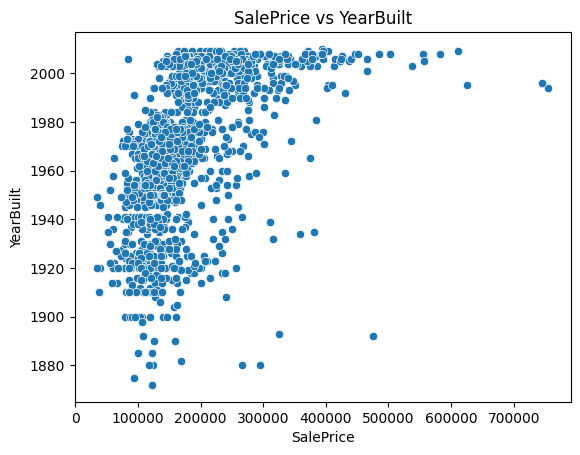

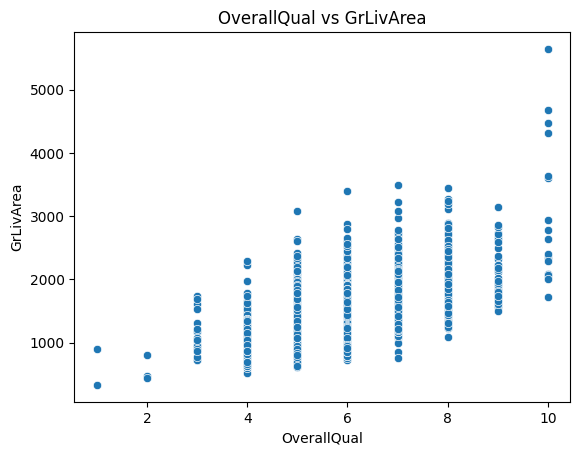

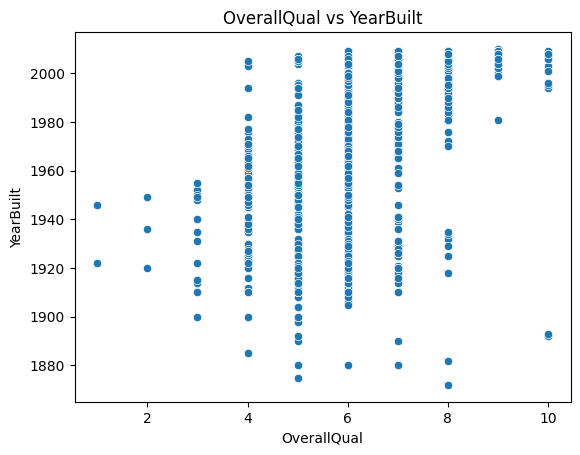

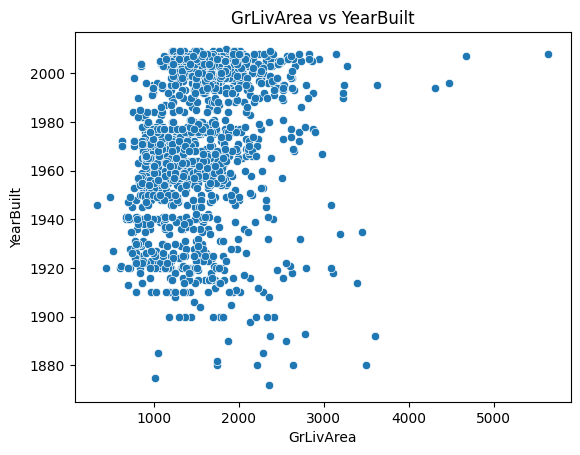

In [18]:
attributes = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt']

for i in range(len(attributes)):
    for j in range(i + 1, len(attributes)):
        x = attributes[i]
        y = attributes[j]
        sns.scatterplot(x=x, y=y, data=data)
        plt.title(f'{x} vs {y}')
        plt.show()


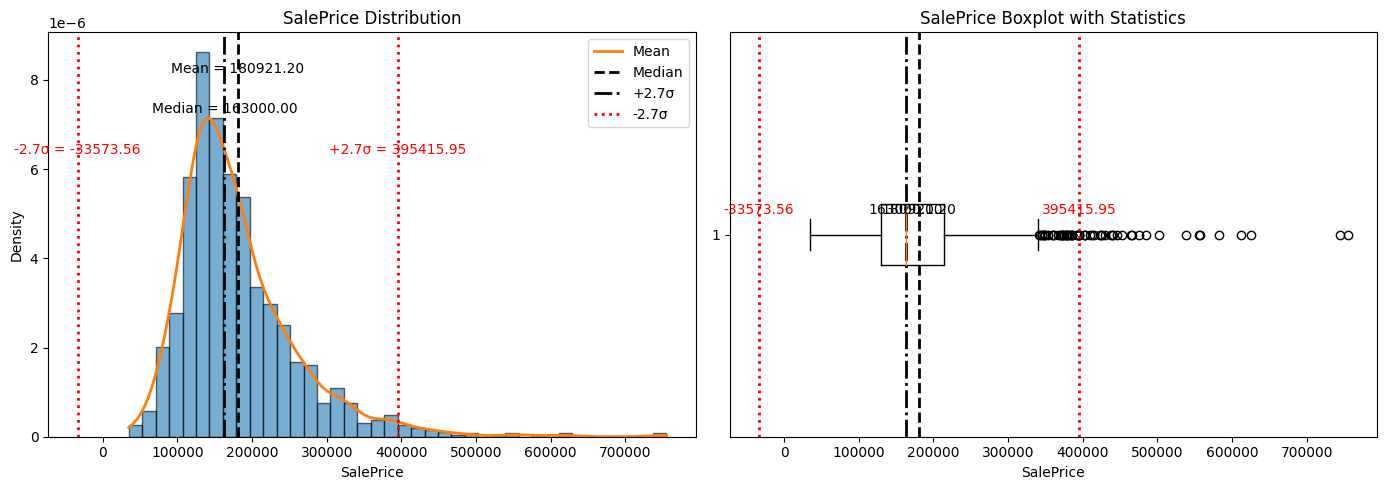

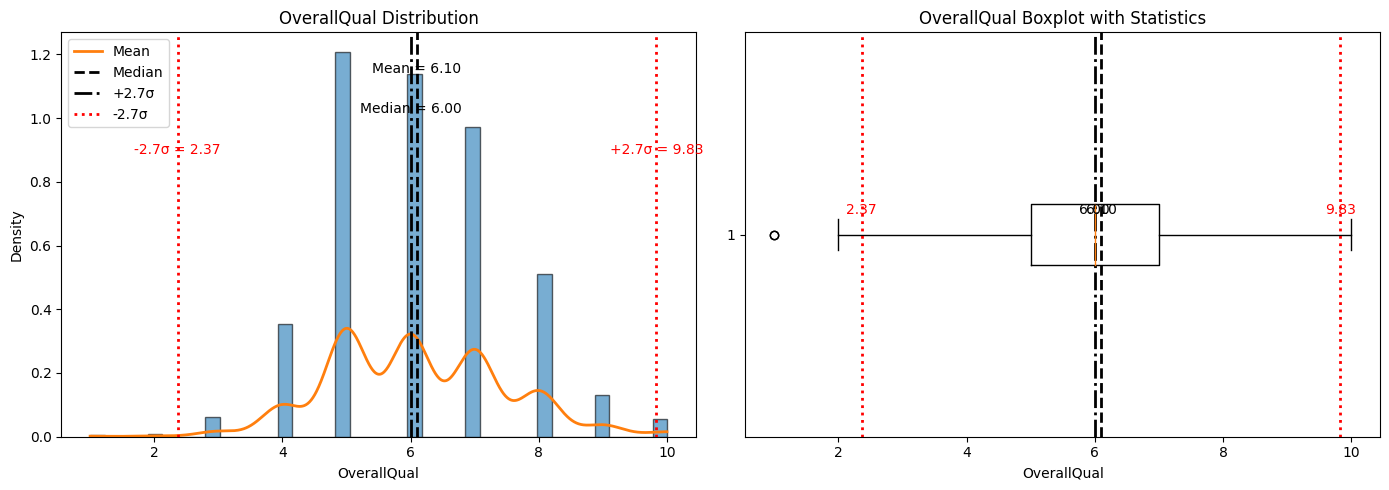

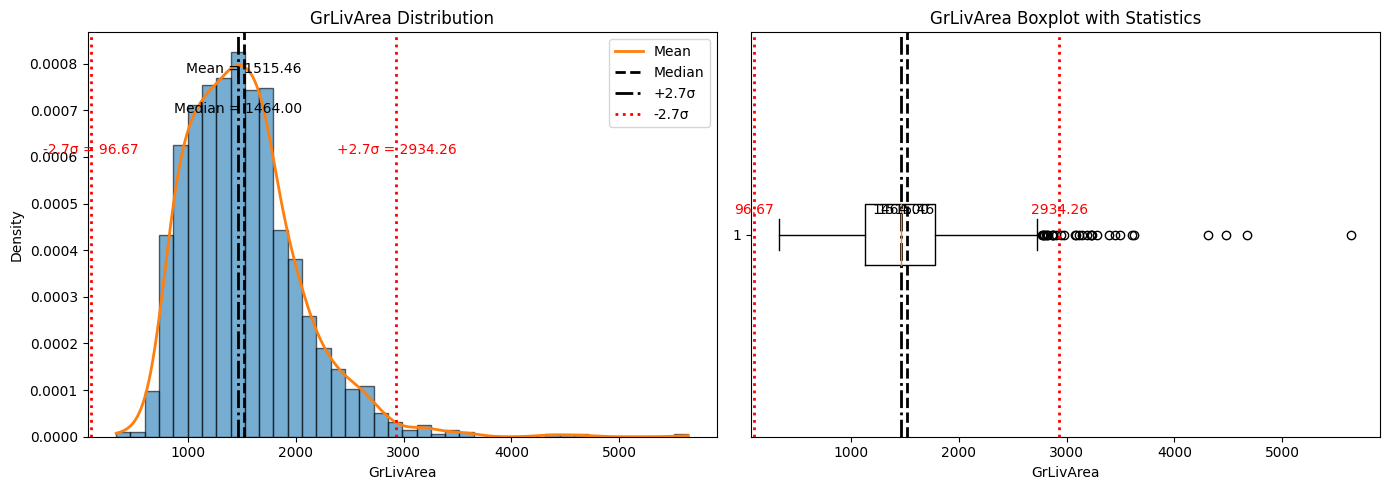

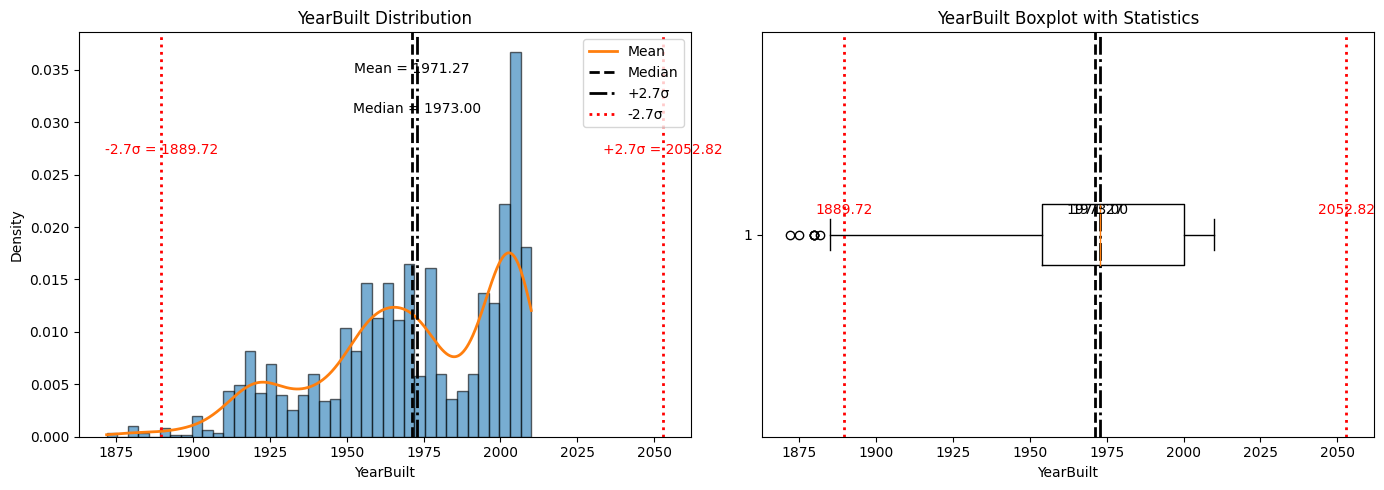

In [23]:
from scipy.stats import gaussian_kde

variables = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt']

for var in variables:
    # Drop missing values
    d = data[var].dropna().values

    # Statistics
    mu = d.mean()
    median = np.median(d)
    sigma = d.std(ddof=1)
    ucl = mu + 2.7 * sigma
    lcl = mu - 2.7 * sigma

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ------------------ Histogram ------------------
    ax = axes[0]
    ax.hist(d, bins=40, density=True, alpha=0.6, edgecolor="black")

    # KDE
    kde = gaussian_kde(d)
    x_vals = np.linspace(d.min(), d.max(), 1000)
    ax.plot(x_vals, kde(x_vals), linewidth=2)

    # Vertical lines
    lines = {
        "Mean": mu,
        "Median": median,
        "+2.7σ": ucl,
        "-2.7σ": lcl
    }
    colors = {
        "Mean": "black",
        "Median": "black",
        "+2.7σ": "red",
        "-2.7σ": "red"
    }
    styles = {
        "Mean": "--",
        "Median": "-.",
        "+2.7σ": ":",
        "-2.7σ": ":"
    }

    for label, x in lines.items():
        ax.axvline(x, linestyle=styles[label], linewidth=2, color=colors[label])
        # Automatic vertical placement of text
        ymax = ax.get_ylim()[1]
        ypos = ymax * (0.9 if label=="Mean" else 0.8 if label=="Median" else 0.7)
        ax.text(x, ypos, f"{label} = {x:.2f}", ha="center", color=colors[label])

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.legend(lines.keys())

    # ------------------ Boxplot ------------------
    ax = axes[1]
    ax.boxplot(d, vert=False)
    for label, x in lines.items():
        ax.axvline(x, linestyle=styles[label], linewidth=2, color=colors[label])
        ax.text(x, 1.05, f"{x:.2f}", ha="center", color=colors[label])

    ax.set_title(f"{var} Boxplot with Statistics")
    ax.set_xlabel(var)

    plt.tight_layout()
    plt.show()


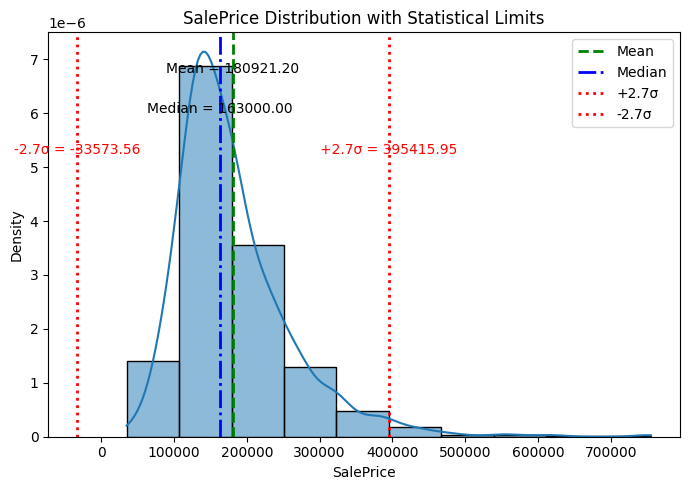

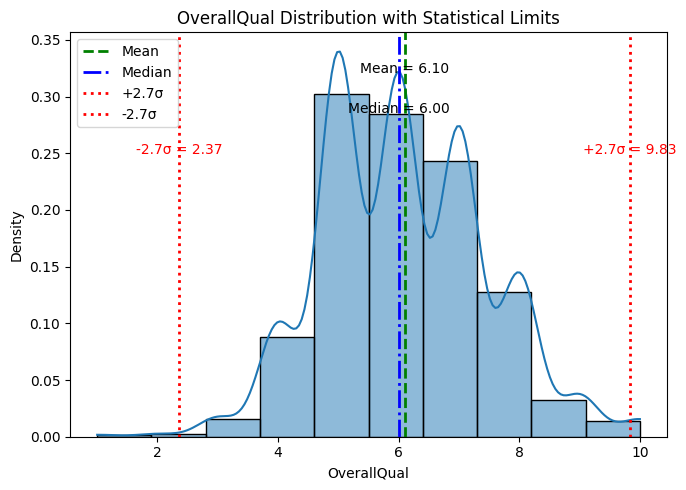

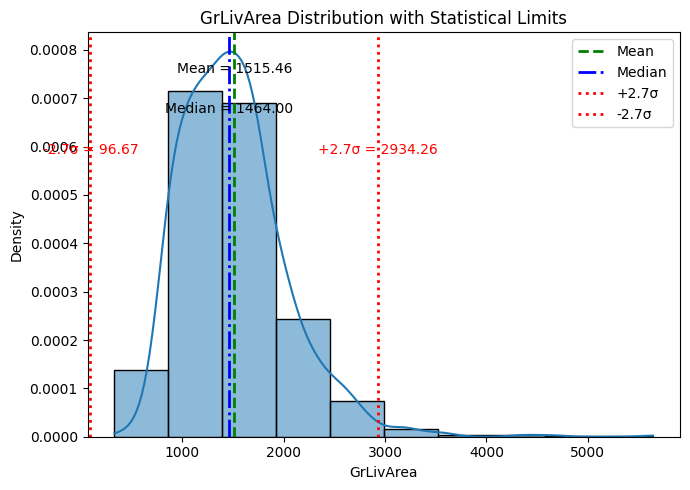

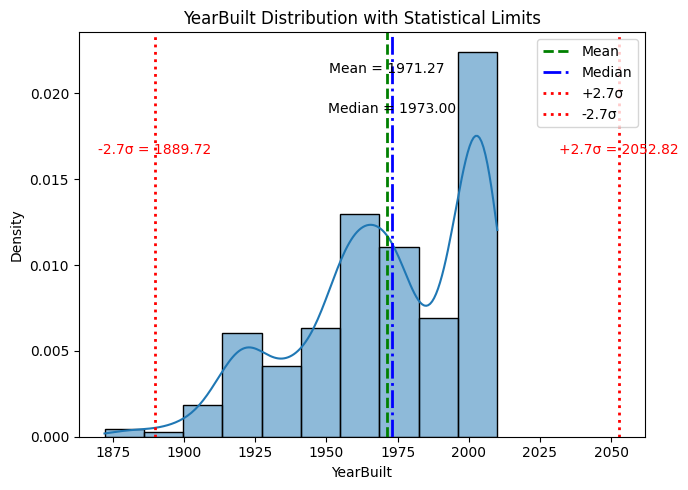

In [20]:
variables = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt']

for var in variables:
    d = data[var].dropna().values  
    
    mu = d.mean()
    median = np.median(d)
    sigma = d.std(ddof=1)
    
    ucl = mu + 2.7 * sigma
    lcl = mu - 2.7 * sigma
    
    plt.figure(figsize=(7,5))
    sns.histplot(d, bins=10, kde=True, stat="density")
    
    # Reference lines
    plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color='green')
    plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color='blue')
    plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
    plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')
    
    # Numeric labels
    ymax = plt.ylim()[1]
    plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
    plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
    plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
    plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')
    
    plt.title(f"{var} Distribution with Statistical Limits")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [21]:

grouped = data.groupby('OverallQual')[['SalePrice', 'GrLivArea', 'YearBuilt']].mean()
print(grouped)




                 SalePrice    GrLivArea    YearBuilt
OverallQual                                         
1             50150.000000   619.000000  1934.000000
2             51770.333333   572.666667  1935.000000
3             87473.750000  1119.150000  1932.700000
4            108420.655172  1106.672414  1948.284483
5            133523.347607  1250.748111  1954.732997
6            161603.034759  1465.874332  1967.636364
7            207716.423197  1703.833856  1988.269592
8            274735.535714  1947.613095  1996.821429
9            367513.023256  2077.511628  2005.116279
10           438588.388889  3001.388889  1991.888889


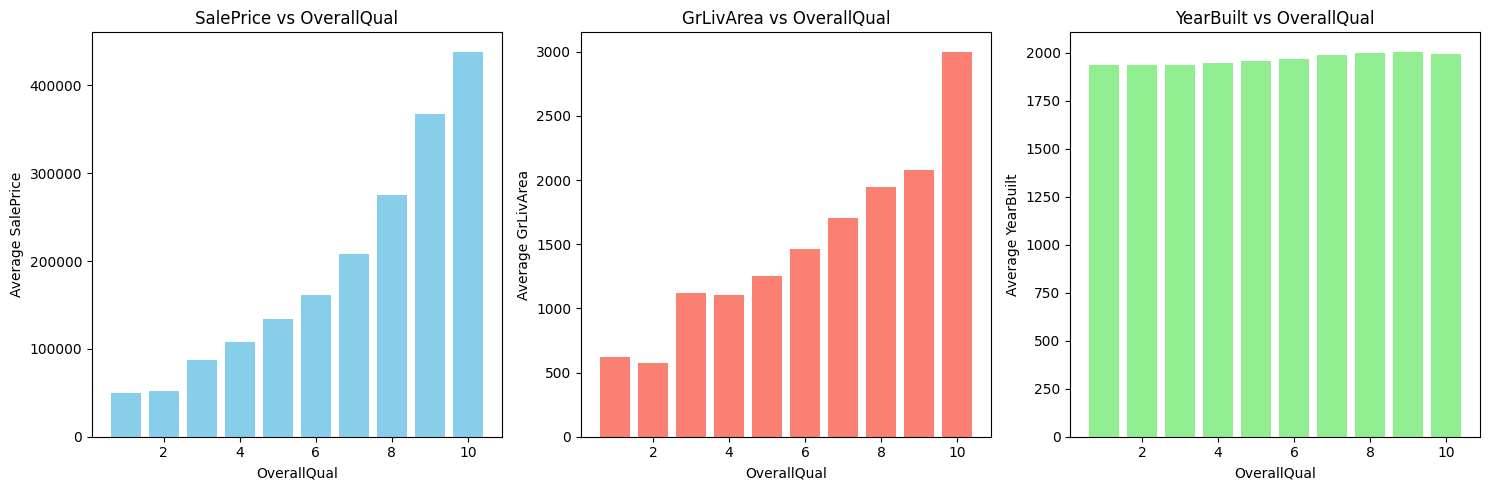

In [22]:
# Set figure size
plt.figure(figsize=(15, 5))

# SalePrice
plt.subplot(1, 3, 1)
plt.bar(grouped.index, grouped['SalePrice'], color='skyblue')
plt.xlabel('OverallQual')
plt.ylabel('Average SalePrice')
plt.title('SalePrice vs OverallQual')

# GrLivArea
plt.subplot(1, 3, 2)
plt.bar(grouped.index, grouped['GrLivArea'], color='salmon')
plt.xlabel('OverallQual')
plt.ylabel('Average GrLivArea')
plt.title('GrLivArea vs OverallQual')

# YearBuilt
plt.subplot(1, 3, 3)
plt.bar(grouped.index, grouped['YearBuilt'], color='lightgreen')
plt.xlabel('OverallQual')
plt.ylabel('Average YearBuilt')
plt.title('YearBuilt vs OverallQual')

plt.tight_layout()
plt.show()


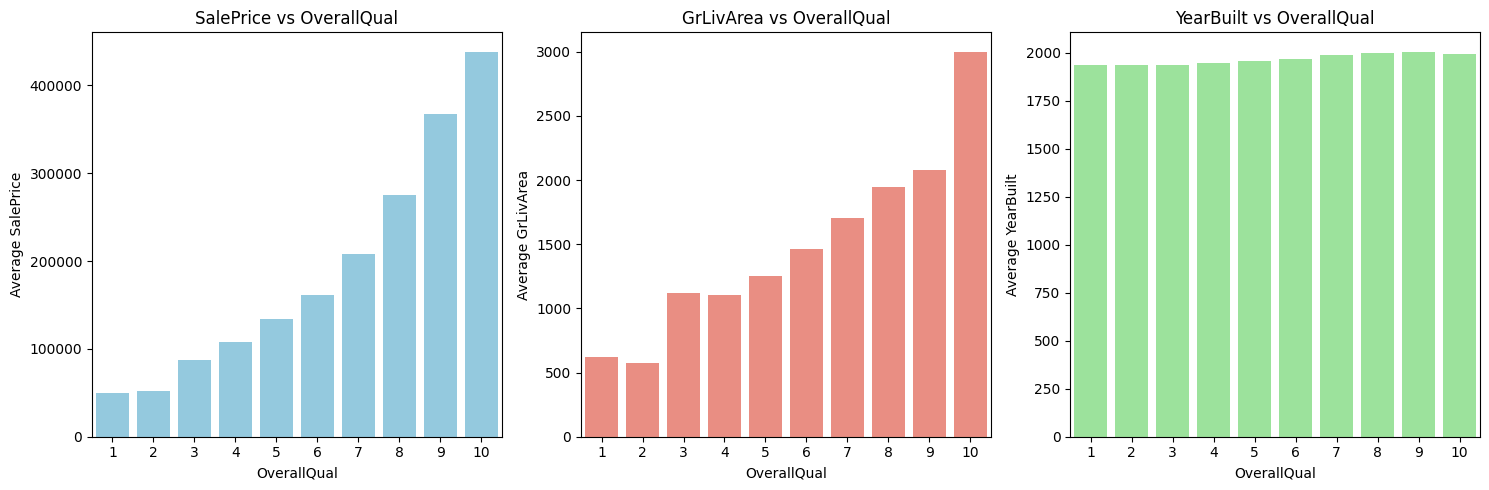

In [25]:
plt.figure(figsize=(15, 5))

# SalePrice
plt.subplot(1, 3, 1)
sns.barplot(
    x='OverallQual', y='SalePrice', data=data,
    color='skyblue', errorbar=None  # future-proof
)
plt.xlabel('OverallQual')
plt.ylabel('Average SalePrice')
plt.title('SalePrice vs OverallQual')

# GrLivArea
plt.subplot(1, 3, 2)
sns.barplot(
    x='OverallQual', y='GrLivArea', data=data,
    color='salmon', errorbar=None
)
plt.xlabel('OverallQual')
plt.ylabel('Average GrLivArea')
plt.title('GrLivArea vs OverallQual')

# YearBuilt
plt.subplot(1, 3, 3)
sns.barplot(
    x='OverallQual', y='YearBuilt', data=data,
    color='lightgreen', errorbar=None
)
plt.xlabel('OverallQual')
plt.ylabel('Average YearBuilt')
plt.title('YearBuilt vs OverallQual')

plt.tight_layout()
plt.show()

In [30]:
numerical_cols = data.select_dtypes(include=np.number).columns
num_cols = len(numerical_cols)
cols_per_row = 5  # adjust as needed
rows = (num_cols + cols_per_row - 1) // cols_per_row

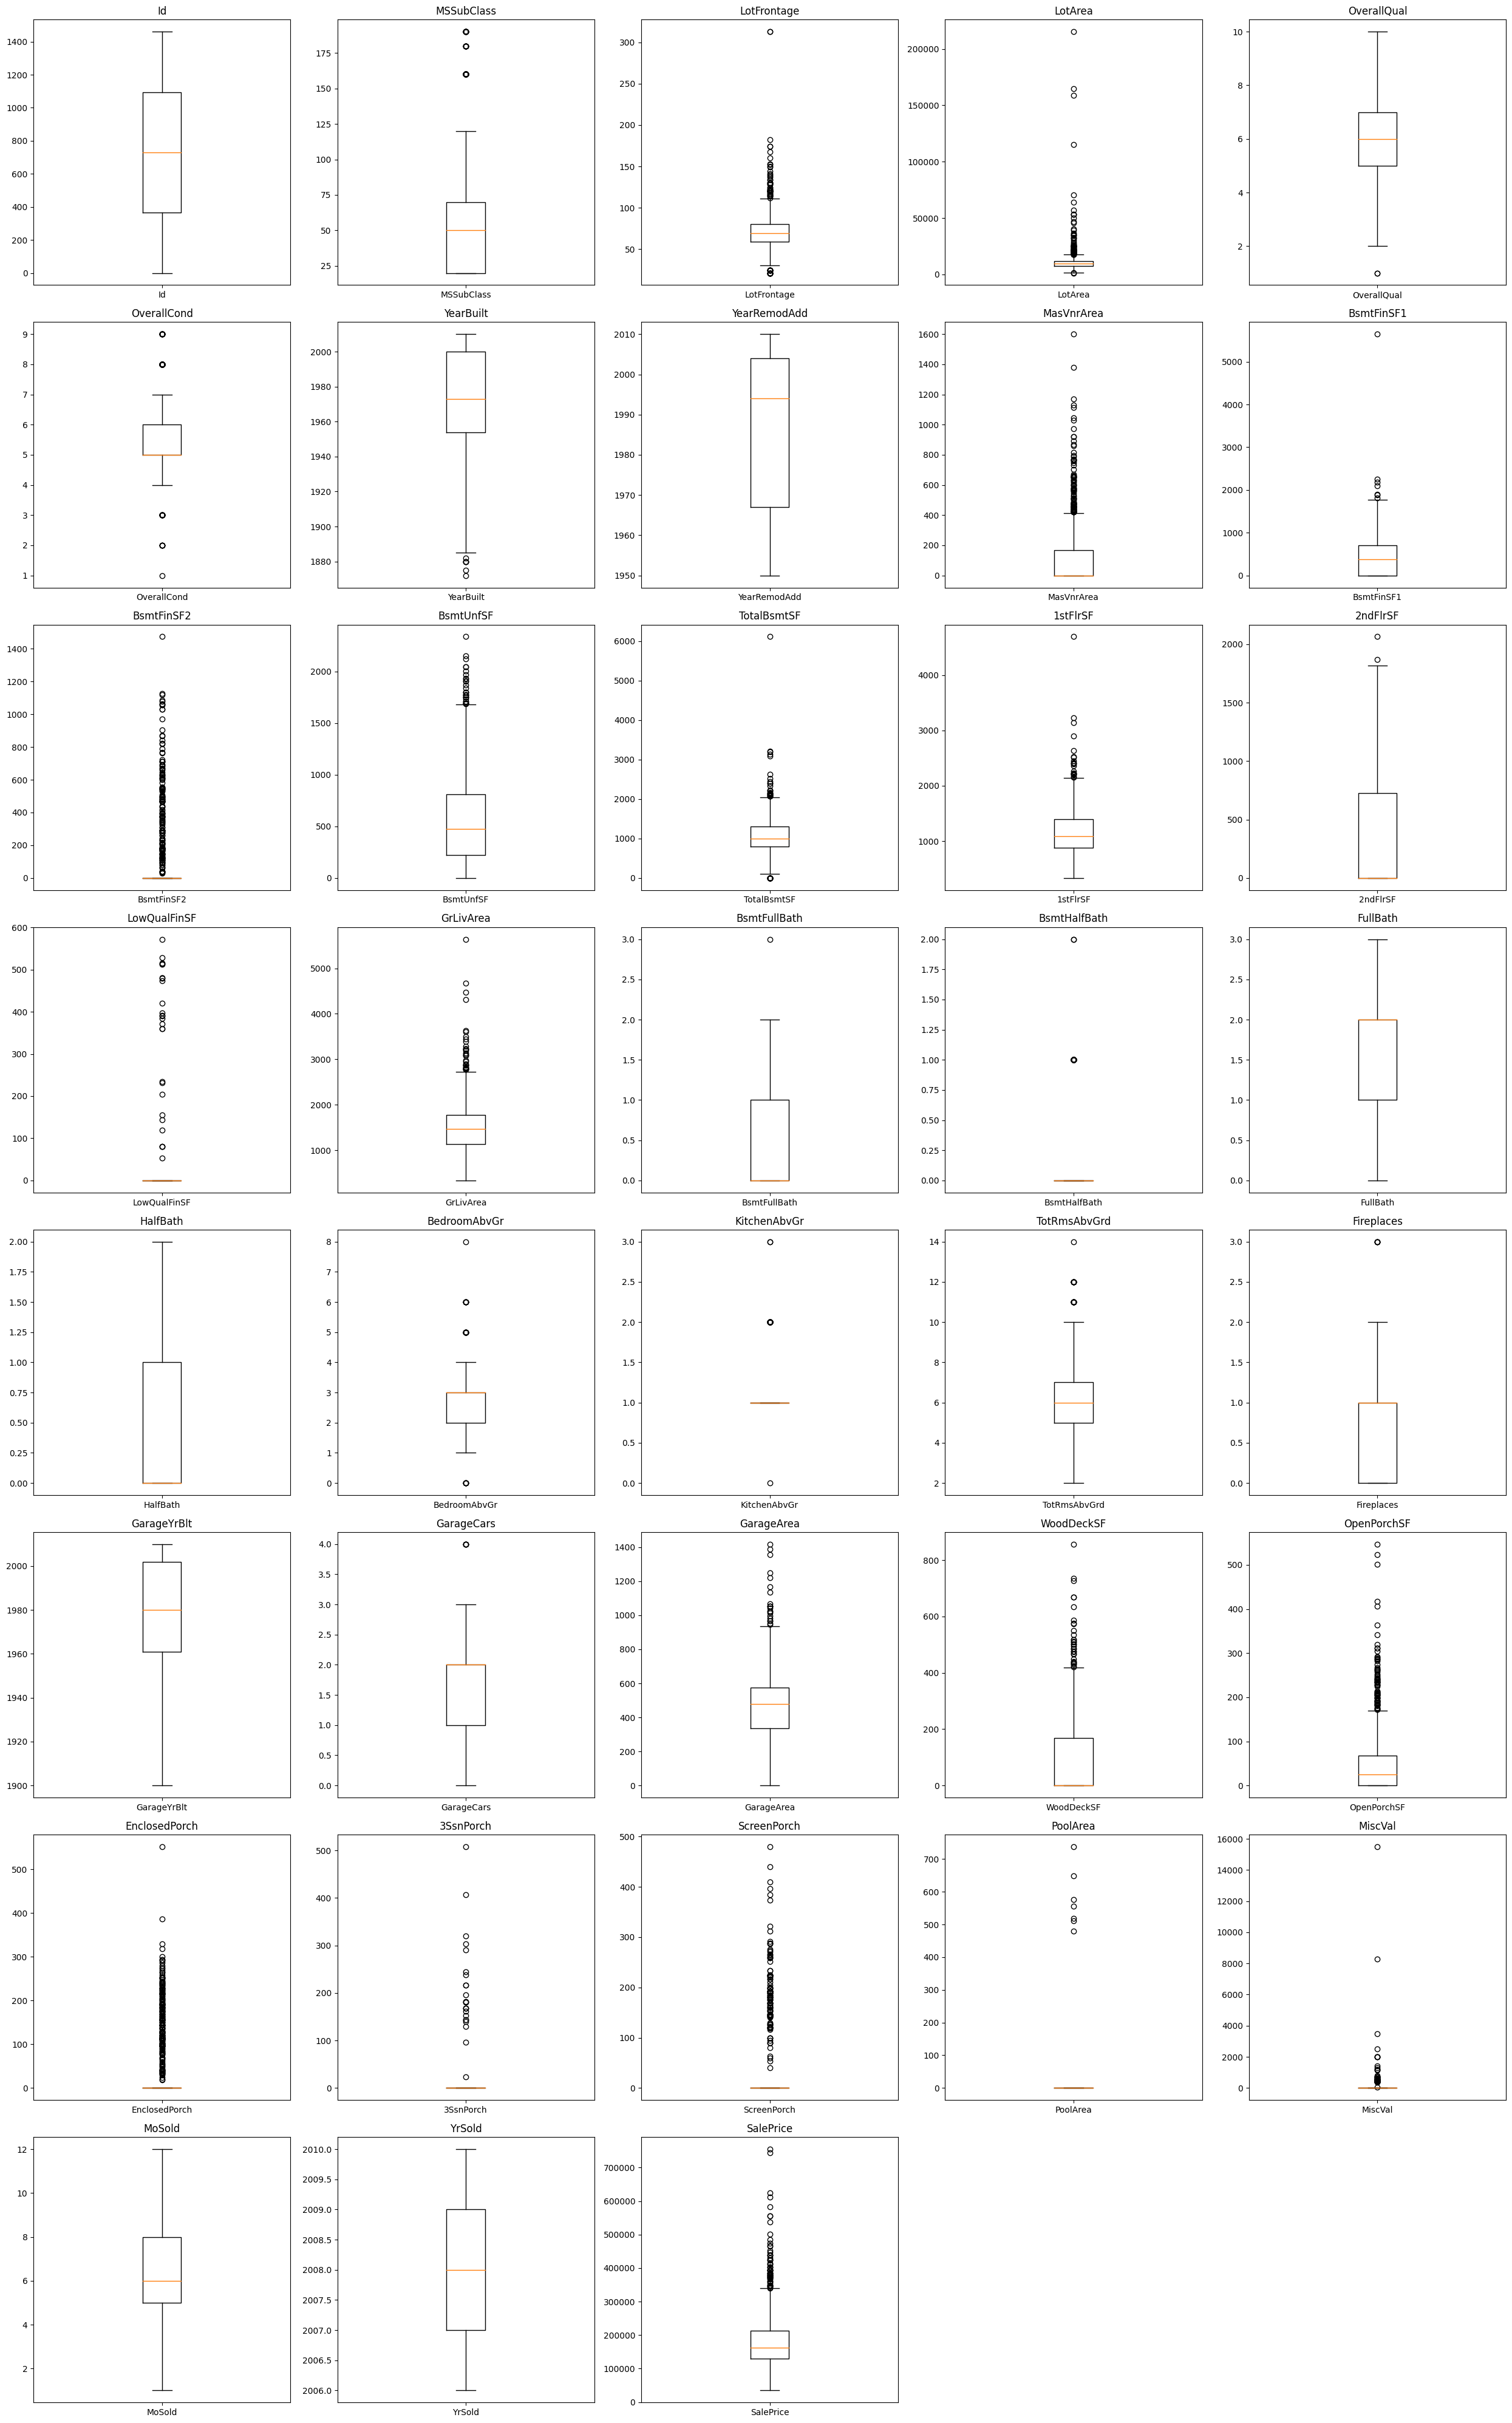

In [31]:
plt.figure(figsize=(5*cols_per_row, 5*rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    plt.boxplot(data[col].dropna(), vert=True)
    plt.title(col)
    plt.xticks([1], [col])

plt.tight_layout()
plt.show()

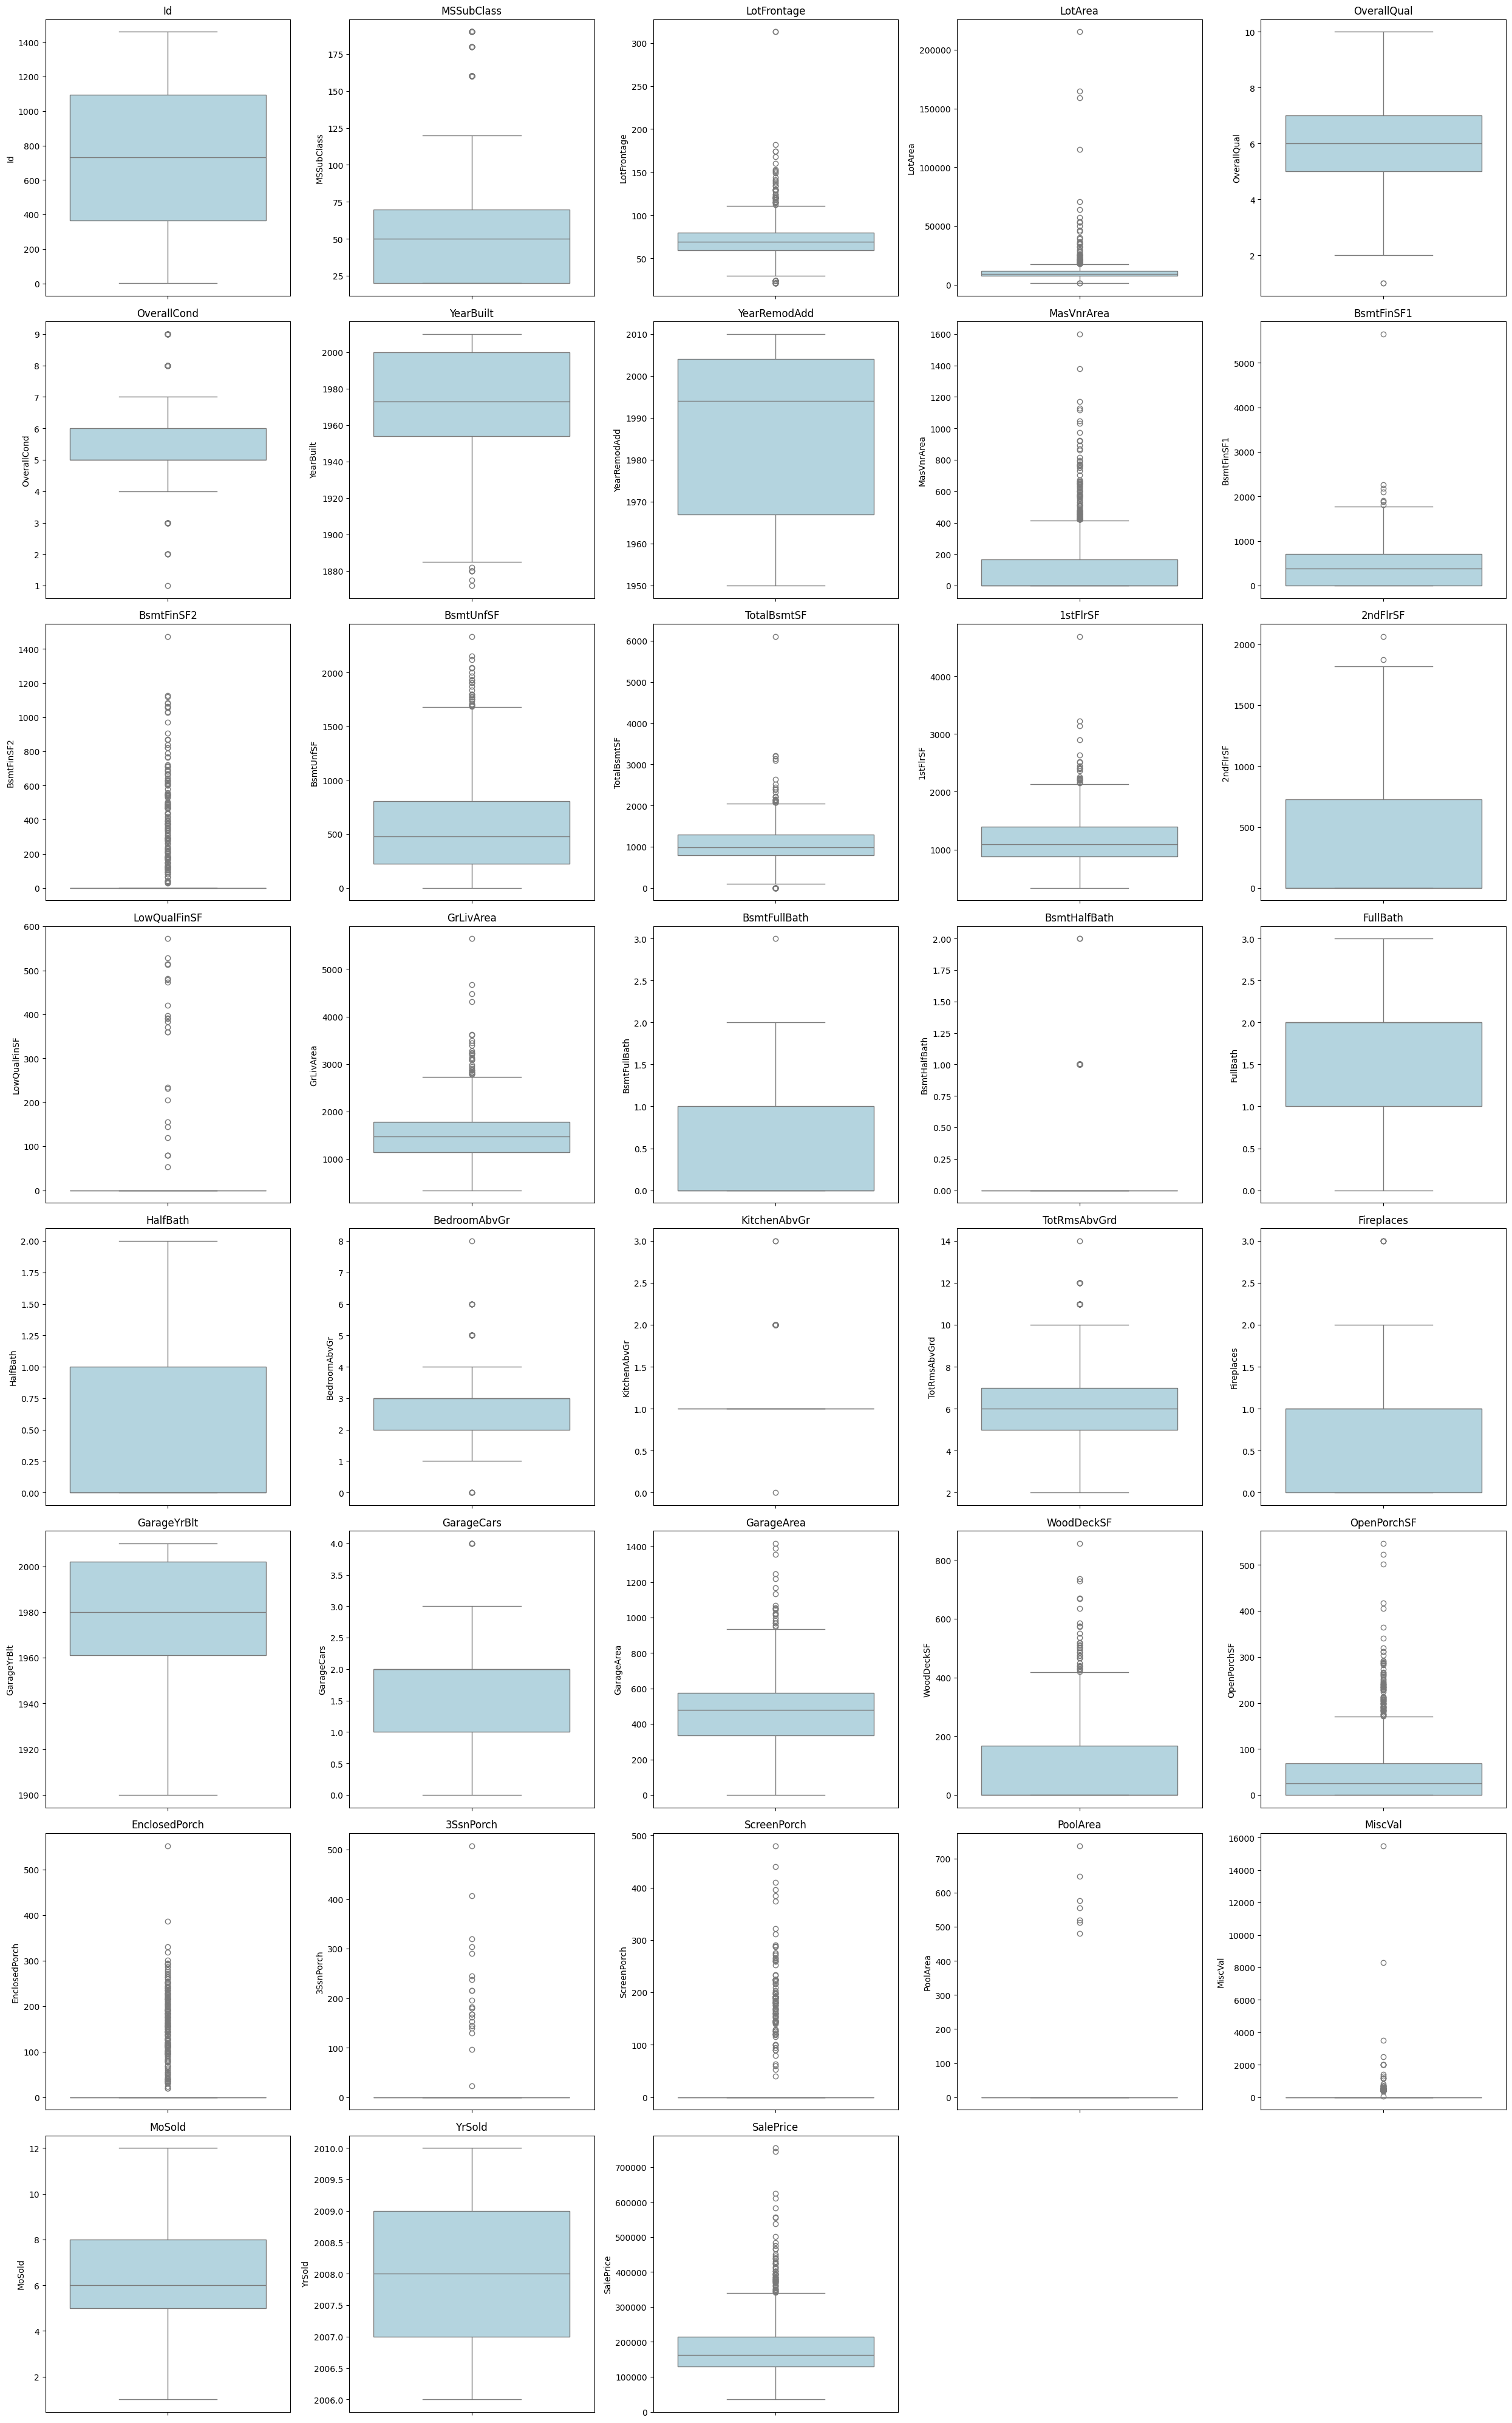

In [32]:
plt.figure(figsize=(5*cols_per_row, 5*rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=data[col], color="lightblue")
    plt.title(col)

plt.tight_layout()
plt.show()